In [3]:
# imports & paths
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import joblib

plt.rcParams['figure.figsize'] = (10,5)


INPUT_PATH = r"D:\bhopal-pollutant-prediction\processed_data\bhopal_aqi_weather_final_clean.csv"
OUTPUT_DIR = Path(r"D:\bhopal-pollutant-prediction\processed_data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_IMPUTED = OUTPUT_DIR / "bhopal_aqi_weather_final_imputed.csv"
PROCESSED_FOR_MODEL = OUTPUT_DIR / "bhopal_aqi_weather_processed_for_model.csv"
SCALER_PATH = OUTPUT_DIR / "scaler.joblib"


In [4]:
# loading
df = pd.read_csv(INPUT_PATH, parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

print("Shape:", df.shape)
print(df.columns)
display(df.head())


Shape: (17040, 49)
Index(['temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'windspeed', 'winddir', 'windgust', 'sealevelpressure', 'cloudcover',
       'visibility', 'solarradiation', 'uvindex', 'PM25_Idgah_Hills',
       'PM10_Idgah_Hills', 'NO_Idgah_Hills', 'SO2_Idgah_Hills',
       'CO_Idgah_Hills', 'O3_Idgah_Hills', 'Benzene_Idgah_Hills',
       'NO2_Idgah_Hills', 'NH3_Idgah_Hills', 'PM25_TT_Nagar', 'PM10_TT_Nagar',
       'NO_TT_Nagar', 'SO2_TT_Nagar', 'CO_TT_Nagar', 'O3_TT_Nagar',
       'NO2_TT_Nagar', 'NH3_TT_Nagar', 'PM25_Paryavaran_Parisar',
       'PM10_Paryavaran_Parisar', 'NO_Paryavaran_Parisar',
       'SO2_Paryavaran_Parisar', 'CO_Paryavaran_Parisar',
       'O3_Paryavaran_Parisar', 'Benzene_Paryavaran_Parisar',
       'NO2_Paryavaran_Parisar', 'NH3_Paryavaran_Parisar', 'year', 'month',
       'day', 'hour', 'dayofweek', 'hour_sin', 'hour_cos', 'month_sin',
       'month_cos'],
      dtype='object')


,temp,feelslike,dew,humidity,precip,precipprob,windspeed,winddir,windgust,sealevelpressure,...,NH3_Paryavaran_Parisar,year,month,day,hour,dayofweek,hour_sin,hour_cos,month_sin,month_cos
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,63.8,63.8,59.6,86.39,0.0,0.0,6.5,98.5,8.3,1016.0,...,38.00,2024,1,1,0,0,0.000000,1.000000,0.5,0.866025
2024-01-01 01:00:00,63.2,63.2,59.1,86.36,0.0,0.0,6.5,103.2,11.2,1016.0,...,32.33,2024,1,1,1,0,0.258819,0.965926,0.5,0.866025
2024-01-01 02:00:00,62.0,62.0,60.5,95.03,0.0,0.0,2.2,360.0,11.0,1014.7,...,30.75,2024,1,1,2,0,0.500000,0.866025,0.5,0.866025
2024-01-01 03:00:00,61.8,61.8,58.6,89.12,0.0,0.0,5.6,104.3,10.5,1015.0,...,28.12,2024,1,1,3,0,0.707107,0.707107,0.5,0.866025
2024-01-01 04:00:00,59.1,59.1,57.6,94.97,0.0,0.0,4.7,96.1,9.4,1016.0,...,30.00,2024,1,1,4,0,0.866025,0.500000,0.5,0.866025


In [5]:
# identifing pollutant & weather columns
aqi_cols = [c for c in df.columns if any(p in c for p in 
            ['PM25','PM10','NO','NO2','SO2','CO','O3','NH3','Benzene'])]
weather_cols = [c for c in df.columns if c in [
    'temp','feelslike','dew','humidity','precip','precipprob',
    'windspeed','winddir','windgust','sealevelpressure',
    'cloudcover','visibility','solarradiation','uvindex'
]]

print("AQI columns:", aqi_cols)
print("Weather columns:", weather_cols)


AQI columns: ['PM25_Idgah_Hills', 'PM10_Idgah_Hills', 'NO_Idgah_Hills', 'SO2_Idgah_Hills', 'CO_Idgah_Hills', 'O3_Idgah_Hills', 'Benzene_Idgah_Hills', 'NO2_Idgah_Hills', 'NH3_Idgah_Hills', 'PM25_TT_Nagar', 'PM10_TT_Nagar', 'NO_TT_Nagar', 'SO2_TT_Nagar', 'CO_TT_Nagar', 'O3_TT_Nagar', 'NO2_TT_Nagar', 'NH3_TT_Nagar', 'PM25_Paryavaran_Parisar', 'PM10_Paryavaran_Parisar', 'NO_Paryavaran_Parisar', 'SO2_Paryavaran_Parisar', 'CO_Paryavaran_Parisar', 'O3_Paryavaran_Parisar', 'Benzene_Paryavaran_Parisar', 'NO2_Paryavaran_Parisar', 'NH3_Paryavaran_Parisar']
Weather columns: ['temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'windspeed', 'winddir', 'windgust', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'uvindex']


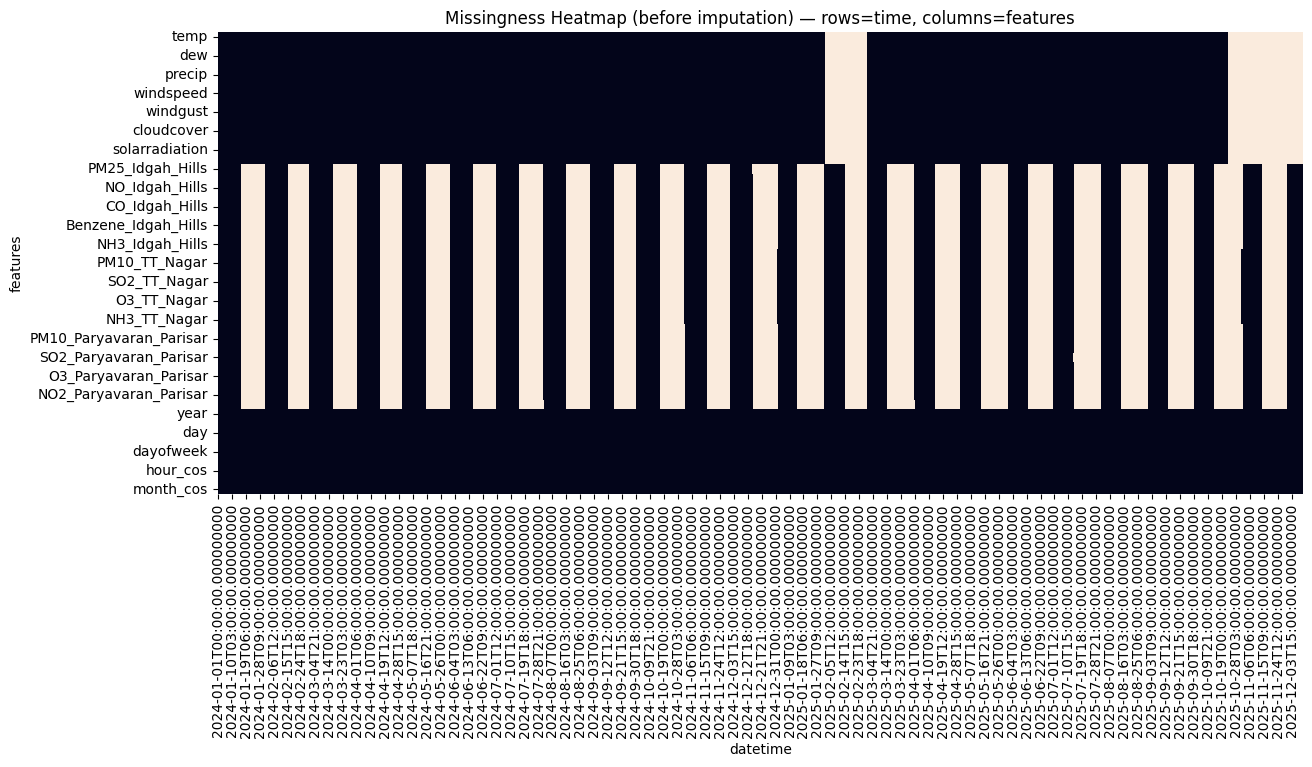

In [6]:
#  missingness heatmap (before)
plt.figure(figsize=(14,6))
sns.heatmap(df.isna().T, cbar=False)
plt.title("Missingness Heatmap (before imputation) — rows=time, columns=features")
plt.ylabel("features")
plt.show()


In [7]:
# keep copy for before/after comparison
df_before = df.copy()


In [8]:
#  initial light interpolation to fill small gaps (<=48 hours for AQI, <=6 for weather)
df_tmp = df.copy()

# AQI small gaps
for col in aqi_cols:
    if col in df_tmp.columns:
        df_tmp[col] = df_tmp[col].interpolate(method='time', limit=48, limit_direction='both')

# weather small gaps
for col in weather_cols:
    if col in df_tmp.columns:
        df_tmp[col] = df_tmp[col].interpolate(method='time', limit=6, limit_direction='both')

print("Initial light interpolation done.")


Initial light interpolation done.


In [9]:
#  STL decomposition per pollutant to fill larger gaps
df_stl = df_tmp.copy()

for col in aqi_cols:
    if col not in df_stl.columns:
        continue
    series = df_stl[col]
    # If almost all NaN skip
    if series.isna().mean() > 0.9:
        print(f"Skipping {col} (too many NaNs).")
        continue
    # Create a temporary series by forward/backfilling to allow STL (we only use seasonal/trend to fill original NaNs)
    temp = series.copy()
    temp = temp.fillna(method='ffill').fillna(method='bfill')  # safe to get seasonal/trend estimate
    try:
        stl = STL(temp, period=24, robust=True).fit()
        reconstructed = stl.trend + stl.seasonal
        # Fill only where original had NaN
        fill_mask = series.isna()
        df_stl.loc[fill_mask, col] = reconstructed[fill_mask]
        print(f"STL filled {fill_mask.sum()} gaps in {col}")
    except Exception as e:
        print(f"STL failed for {col}: {e}")

# update df_tmp
df_tmp = df_stl
print("STL-based filling done.")


C:\Users\MADHURA\AppData\Local\Temp\ipykernel_23968\51657762.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = temp.fillna(method='ffill').fillna(method='bfill')  # safe to get seasonal/trend estimate


STL filled 6767 gaps in PM25_Idgah_Hills


C:\Users\MADHURA\AppData\Local\Temp\ipykernel_23968\51657762.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = temp.fillna(method='ffill').fillna(method='bfill')  # safe to get seasonal/trend estimate


STL filled 6757 gaps in PM10_Idgah_Hills


C:\Users\MADHURA\AppData\Local\Temp\ipykernel_23968\51657762.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = temp.fillna(method='ffill').fillna(method='bfill')  # safe to get seasonal/trend estimate


...

STL filled 6752 gaps in Benzene_Paryavaran_Parisar


C:\Users\MADHURA\AppData\Local\Temp\ipykernel_23968\51657762.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = temp.fillna(method='ffill').fillna(method='bfill')  # safe to get seasonal/trend estimate


STL filled 6753 gaps in NO2_Paryavaran_Parisar


C:\Users\MADHURA\AppData\Local\Temp\ipykernel_23968\51657762.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = temp.fillna(method='ffill').fillna(method='bfill')  # safe to get seasonal/trend estimate


STL filled 6770 gaps in NH3_Paryavaran_Parisar
STL-based filling done.


In [10]:
#  KNN imputer on numeric columns to capture multivariate relations
num_cols = df_tmp.select_dtypes(include=[np.number]).columns.tolist()

imputer = KNNImputer(n_neighbors=5, weights="distance")
arr = imputer.fit_transform(df_tmp[num_cols])
df_knn = pd.DataFrame(arr, index=df_tmp.index, columns=num_cols)

# replace numeric part
df_filled = df_tmp.copy()
df_filled[num_cols] = df_knn

print("KNN imputation done. Remaining NaNs per column:")
print(df_filled.isna().sum()[df_filled.isna().sum() > 0])


KNN imputation done. Remaining NaNs per column:
Series([], dtype: int64)


In [11]:
# final light interpolation and edge fill
df_filled[aqi_cols] = df_filled[aqi_cols].interpolate(method='time', limit=168, limit_direction='both')  # up to 1 week if needed
df_filled[weather_cols] = df_filled[weather_cols].ffill().bfill()

print("After final interpolation, remaining NaNs:")
print(df_filled.isna().sum().sort_values(ascending=False).head(20))


After final interpolation, remaining NaNs:
temp                0
feelslike           0
dew                 0
humidity            0
precip              0
precipprob          0
windspeed           0
winddir             0
windgust            0
sealevelpressure    0
cloudcover          0
visibility          0
solarradiation      0
uvindex             0
PM25_Idgah_Hills    0
PM10_Idgah_Hills    0
NO_Idgah_Hills      0
SO2_Idgah_Hills     0
CO_Idgah_Hills      0
O3_Idgah_Hills      0
dtype: int64


In [12]:
# outlier clipping (IQR)
def clip_iqr(df_in):
    dfc = df_in.copy()
    for c in dfc.select_dtypes(include=[np.number]).columns:
        Q1 = dfc[c].quantile(0.25)
        Q3 = dfc[c].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        dfc[c] = dfc[c].clip(lower, upper)
    return dfc

df_clipped = clip_iqr(df_filled)
print("Outlier clipping done.")


Outlier clipping done.


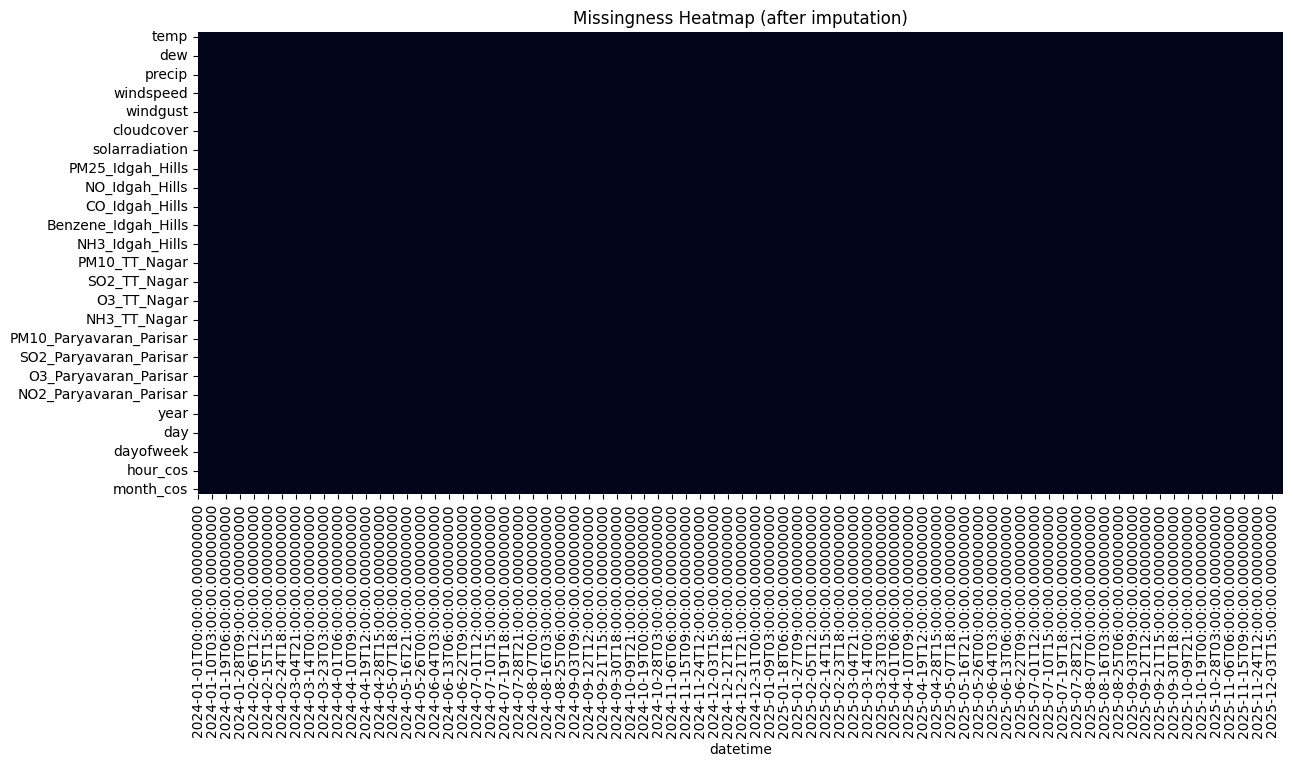

Total remaining NaNs: 0


In [13]:
#  missingness heatmap (after)
plt.figure(figsize=(14,6))
sns.heatmap(df_clipped.isna().T, cbar=False)
plt.title("Missingness Heatmap (after imputation)")
plt.show()

print("Total remaining NaNs:", df_clipped.isna().sum().sum())


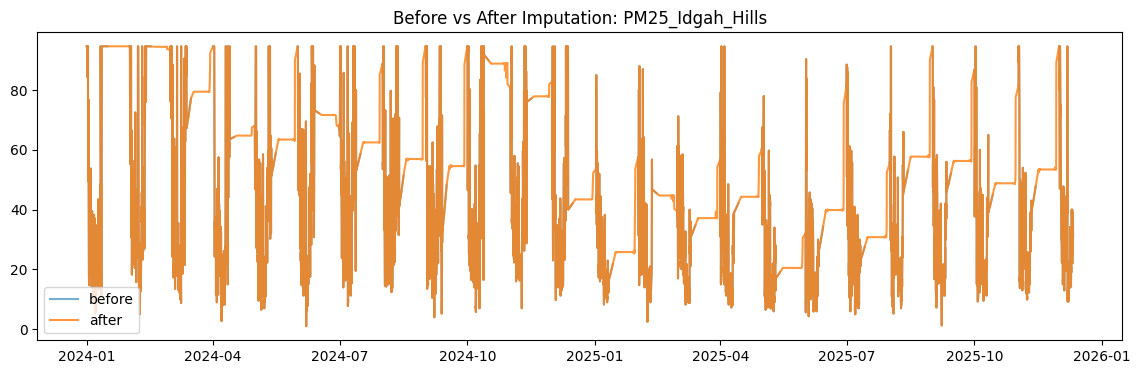

In [14]:
# before/after comparison (example for PM25_Idgah_Hills if present)
col_example = None
for x in aqi_cols:
    if 'PM25' in x:
        col_example = x
        break

if col_example:
    plt.figure(figsize=(14,4))
    plt.plot(df_before[col_example].index, df_before[col_example], label='before', alpha=0.6)
    plt.plot(df_clipped[col_example].index, df_clipped[col_example], label='after', alpha=0.8)
    plt.title(f"Before vs After Imputation: {col_example}")
    plt.legend()
    plt.show()
else:
    print("No PM25 column found to compare.")


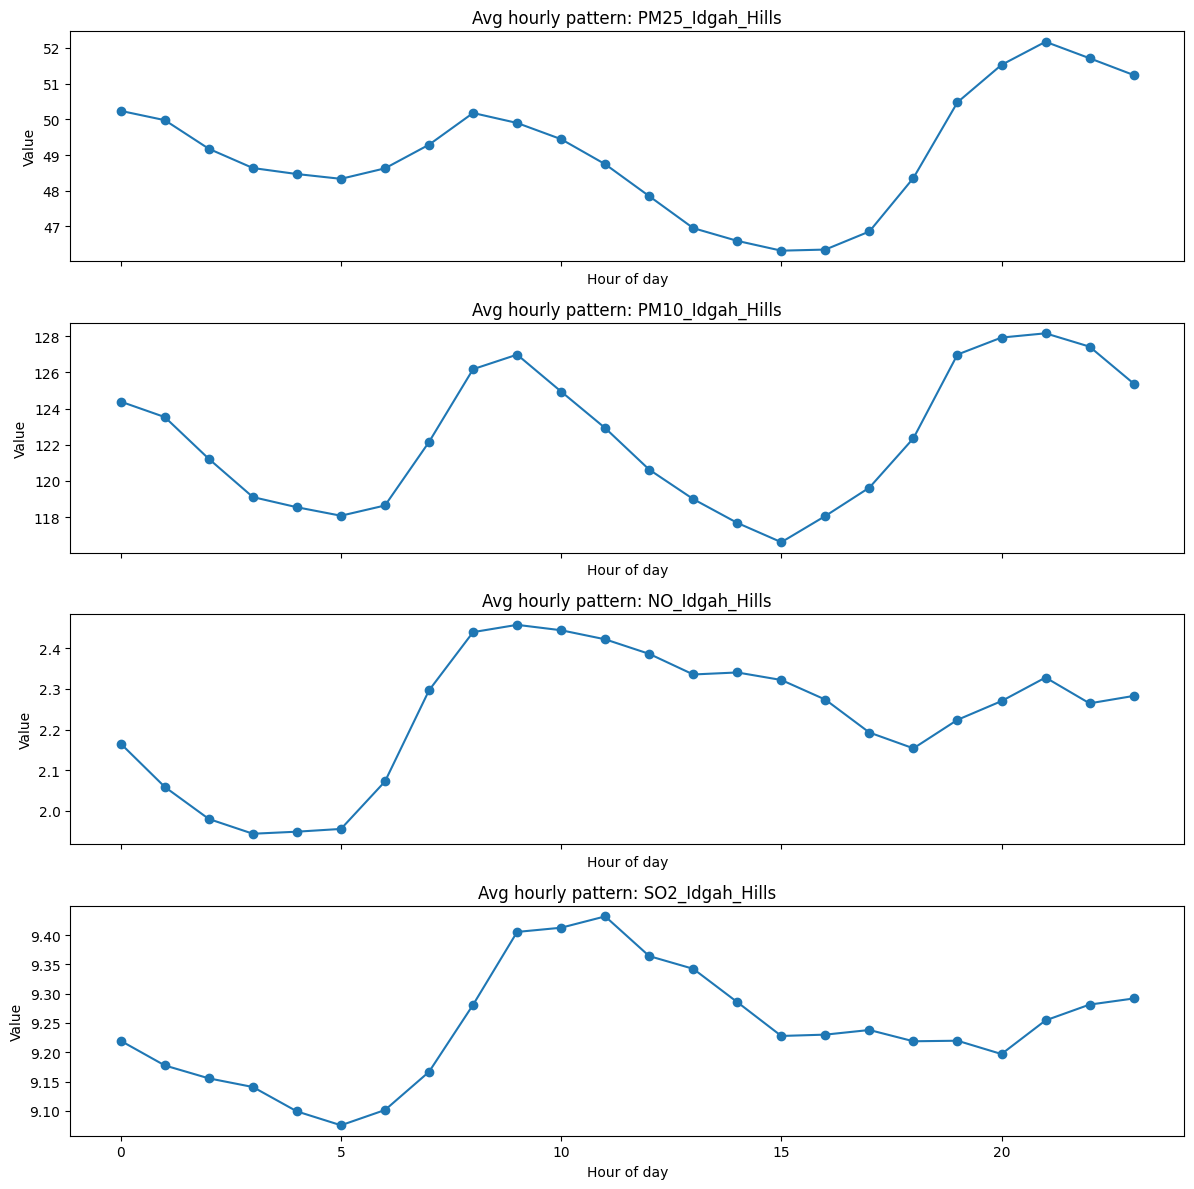

In [15]:
#  pollutant daily pattern (mean by hour)
df_hour = df_clipped.copy()
df_hour['hour'] = df_hour.index.hour

fig, ax = plt.subplots(len(aqi_cols[:4]), 1, figsize=(12, 3*len(aqi_cols[:4])), sharex=True)
for i, col in enumerate(aqi_cols[:4]):  # plot first 4 pollutants to avoid overcrowding
    hourly = df_hour.groupby('hour')[col].mean()
    ax[i].plot(hourly.index, hourly.values, marker='o')
    ax[i].set_title(f"Avg hourly pattern: {col}")
    ax[i].set_xlabel("Hour of day")
    ax[i].set_ylabel("Value")
plt.tight_layout()
plt.show()


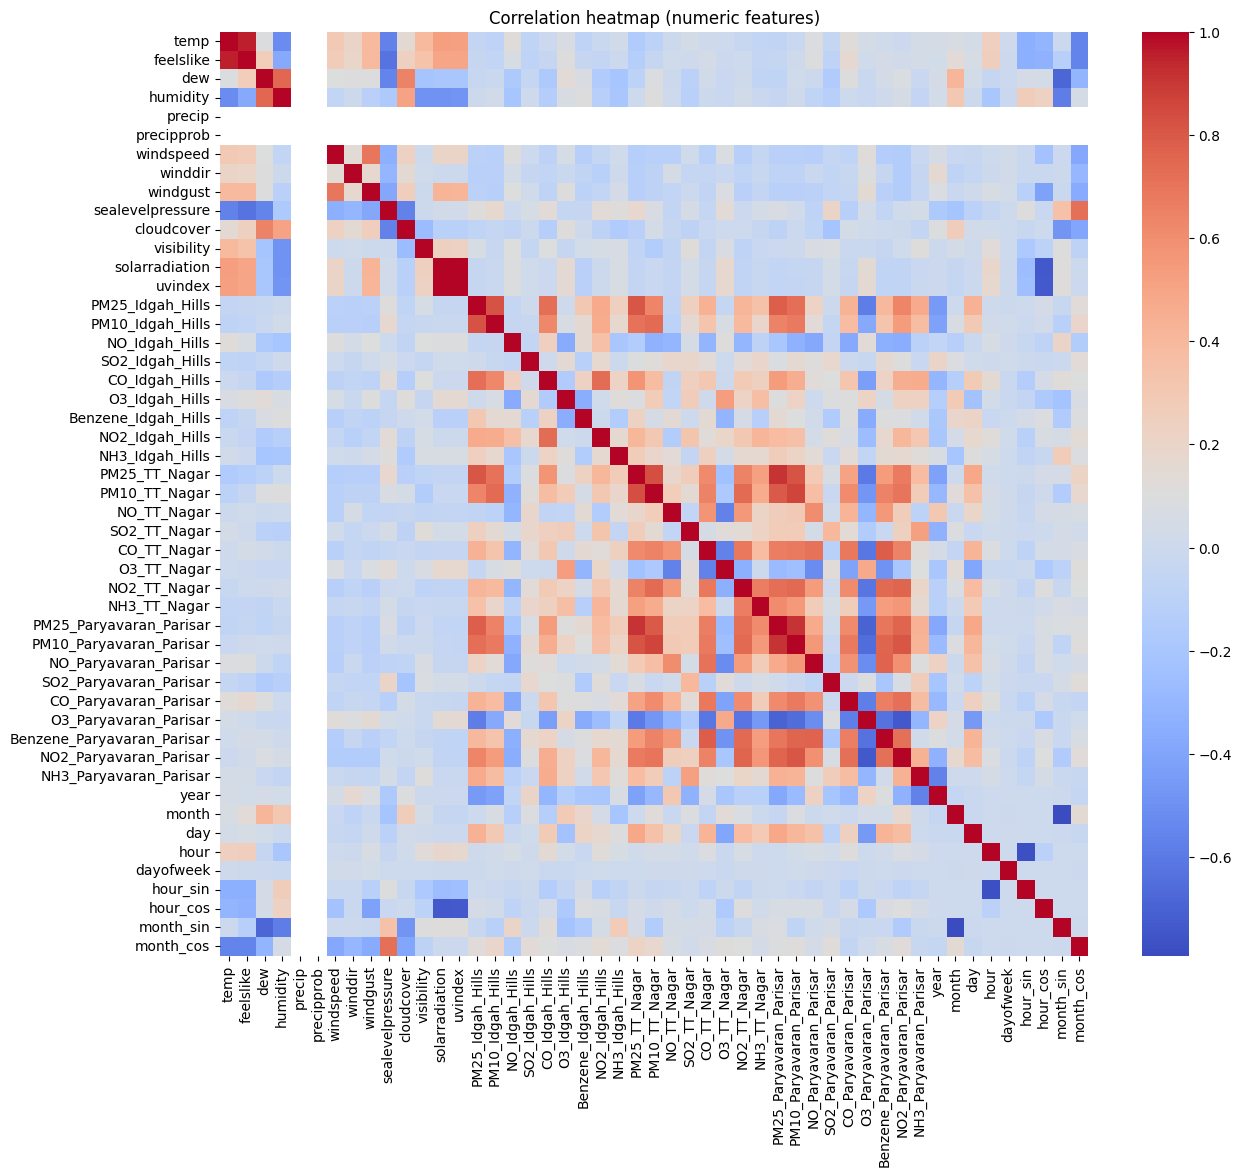

In [16]:
#  correlation heatmap (subset to numeric)
plt.figure(figsize=(14,12))
corr = df_clipped.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation heatmap (numeric features)")
plt.show()


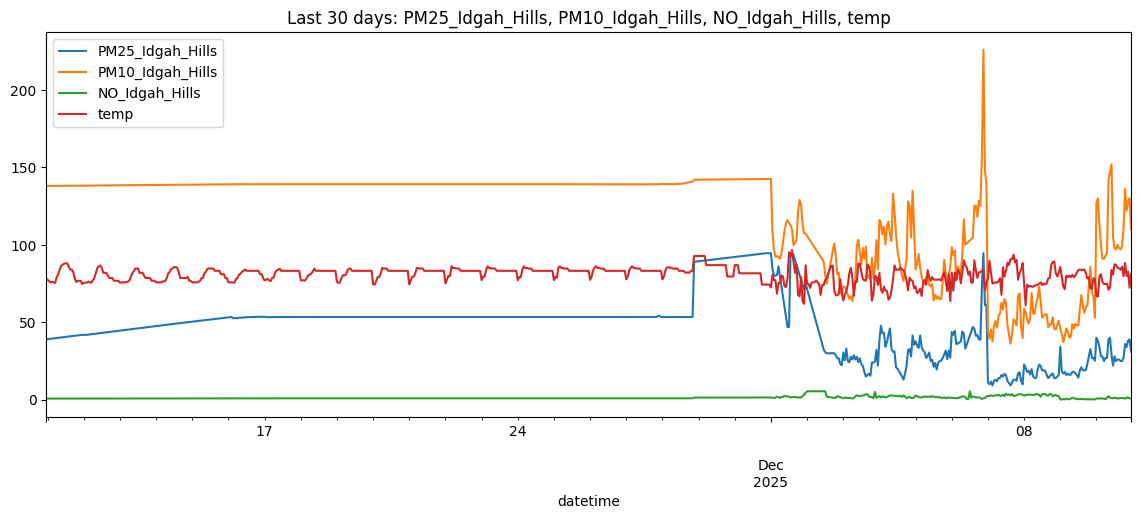

In [17]:
#  time series zoom (choose a recent month)
start = df_clipped.index.max() - pd.Timedelta(days=30)
end = df_clipped.index.max()
cols_to_plot = aqi_cols[:3] + weather_cols[:1]  # example: first 3 pollutants + temp

df_clipped.loc[start:end, cols_to_plot].plot(subplots=False, figsize=(14,5))
plt.title(f"Last 30 days: {', '.join(cols_to_plot)}")
plt.show()


In [18]:
#  create lag + rolling features (example for PM25_Idgah_Hills)
processed = df_clipped.copy()

# lags for PM25 (choose master station if multiple), try to pick one PM25 column
pm25_col = None
for c in processed.columns:
    if 'PM25' in c:
        pm25_col = c
        break

lags = [1, 3, 6, 12, 24]
for lag in lags:
    processed[f"{pm25_col}_lag_{lag}"] = processed[pm25_col].shift(lag)

# Rolling means
processed[f"{pm25_col}_rolling_24"] = processed[pm25_col].rolling(window=24, min_periods=1).mean()
processed = processed.dropna()  # drop rows with NaNs created by lags
print("Created lag & rolling features. Shape:", processed.shape)


Created lag & rolling features. Shape: (17016, 55)


In [19]:
# scaling (StandardScaler) and save scaler
num_features = processed.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
processed[num_features] = scaler.fit_transform(processed[num_features])

# save scaler
joblib.dump(scaler, SCALER_PATH)
print("Scaler saved to", SCALER_PATH)


Scaler saved to D:\bhopal-pollutant-prediction\processed_data\scaler.joblib


In [20]:
#  save CSVs
df_clipped.reset_index().to_csv(FINAL_IMPUTED, index=False)
processed.reset_index().to_csv(PROCESSED_FOR_MODEL, index=False)

print("Saved:")
print(" - Imputed dataset:", FINAL_IMPUTED)
print(" - Processed (lags, scaled) dataset for modeling:", PROCESSED_FOR_MODEL)


Saved:
 - Imputed dataset: D:\bhopal-pollutant-prediction\processed_data\bhopal_aqi_weather_final_imputed.csv
 - Processed (lags, scaled) dataset for modeling: D:\bhopal-pollutant-prediction\processed_data\bhopal_aqi_weather_processed_for_model.csv
